In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loaded: results/value_only/0/training_logs.csv
Loaded: results/value_only/1/training_logs.csv
Loaded: results/value_only/2/training_logs.csv
Loaded: results/value_only/3/training_logs.csv
Loaded: results/value_only/4/training_logs.csv
Loaded: results/value_only/5/training_logs.csv
Loaded: results/value_only/6/training_logs.csv
Loaded: results/value_only/7/training_logs.csv
Loaded: results/value_only/8/training_logs.csv
Loaded: results/value_only/9/training_logs.csv
Loaded: results/value_only/10/training_logs.csv
Loaded: results/both/0/training_logs.csv
Loaded: results/both/1/training_logs.csv
Loaded: results/both/2/training_logs.csv
Loaded: results/both/3/training_logs.csv
Loaded: results/both/4/training_logs.csv
Loaded: results/both/5/training_logs.csv
Loaded: results/both/6/training_logs.csv
Loaded: results/both/7/training_logs.csv
Loaded: results/both/8/training_logs.csv
Loaded: results/both/9/training_logs.csv
Loaded: results/both/10/training_logs.csv
Loaded: results/obs_only/0/tra

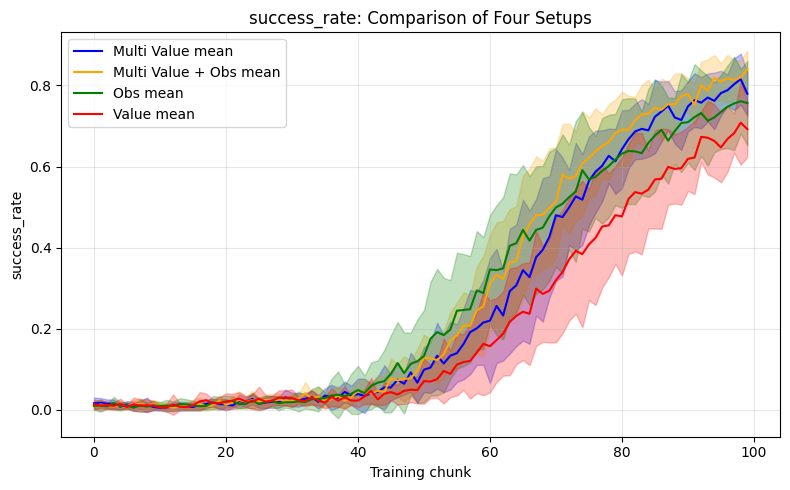

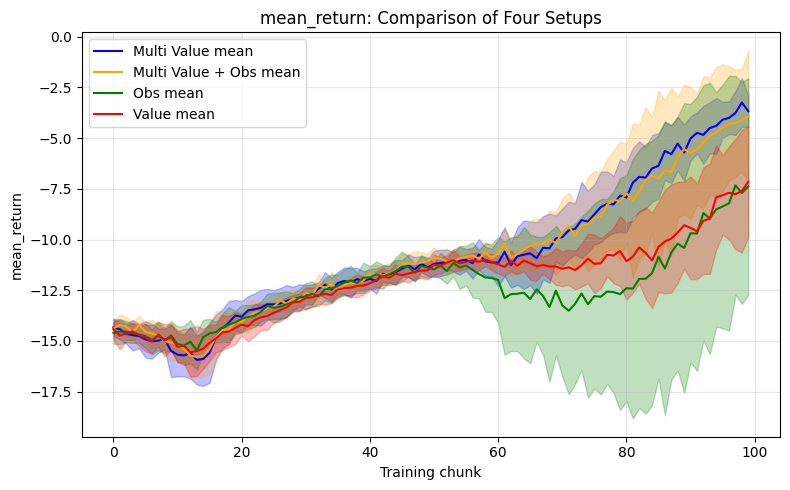

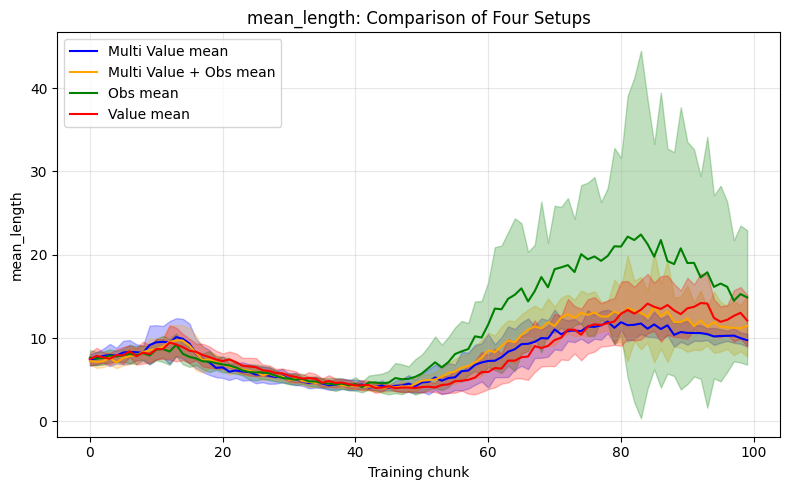

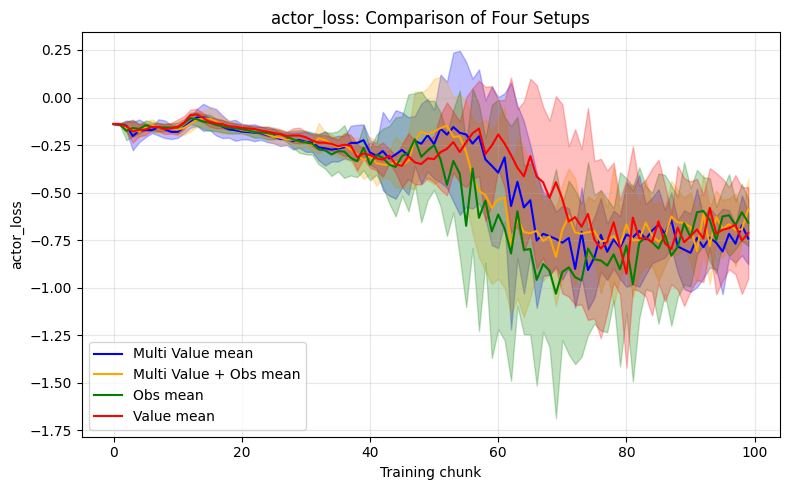

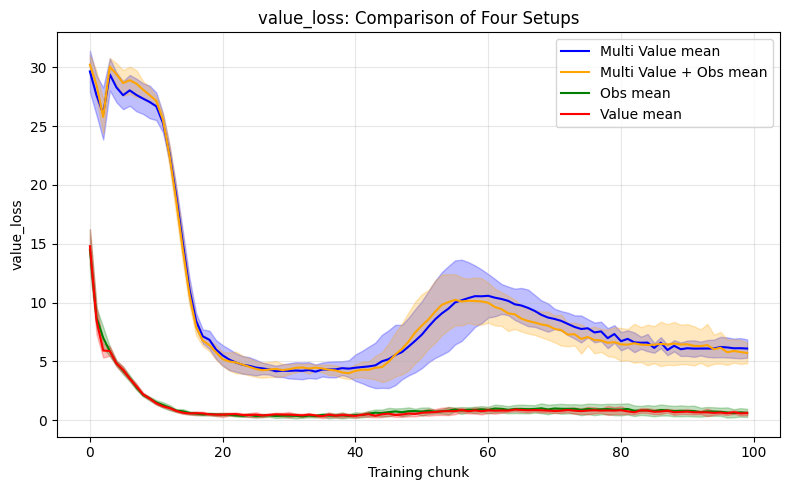

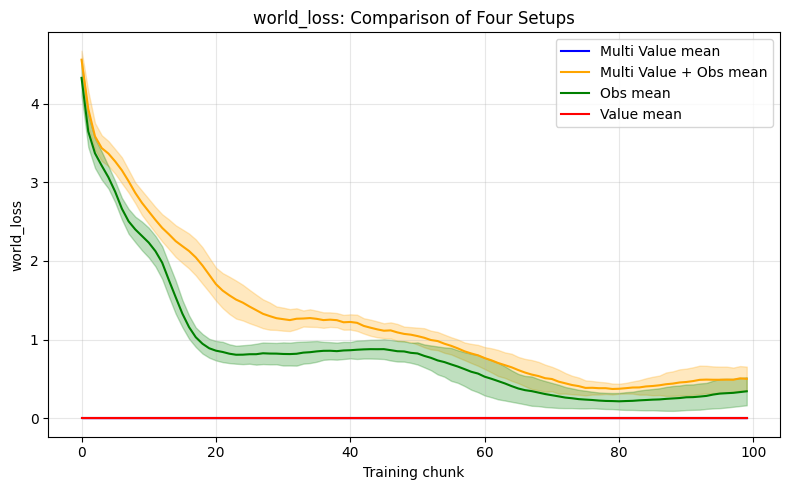

In [ ]:


# -------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------
EXPERIMENTS = [
    ("results/value_only", "Multi Value"),
    ("results/both", "Multi Value + Obs"),
    ("results/obs_only", "Obs"),
    ("results/single_value", "Value"),
]

CSV_NAME = "training_logs.csv"

METRICS = [
    "success_rate", "mean_return", "mean_length",
    "actor_loss", "value_loss", "world_loss"
]

COLORS = ["blue", "orange", "green", "red"]  # one for each experiment


# -------------------------------------------------------------------
# HELPER: Load all replicates from a single experiment folder
# -------------------------------------------------------------------
def load_experiment(base_dir):
    replicate_dfs = []

    folders = [f for f in os.listdir(base_dir) if f.isdigit()]
    folders = sorted(folders, key=lambda x: int(x))

    for folder in folders:
        csv_path = os.path.join(base_dir, folder, CSV_NAME)
        if os.path.isfile(csv_path):
            df = pd.read_csv(csv_path)
            df["chunk"] = np.arange(len(df))
            df["replicate"] = int(folder)
            replicate_dfs.append(df)
            print(f"Loaded: {csv_path}")

    if len(replicate_dfs) == 0:
        raise RuntimeError(f"No CSV logs found in {base_dir}")

    return pd.concat(replicate_dfs, ignore_index=True)


# -------------------------------------------------------------------
# LOAD AND PROCESS ALL FOUR EXPERIMENTS
# -------------------------------------------------------------------
experiment_stats = []  # list of (name, mean_df, std_df)

for (path, name) in EXPERIMENTS:
    data = load_experiment(path)
    mean_df = data.groupby("chunk")[METRICS].mean()
    std_df = data.groupby("chunk")[METRICS].std()
    experiment_stats.append((name, mean_df, std_df))


# -------------------------------------------------------------------
# PLOTTING — all experiments on the same axes
# -------------------------------------------------------------------
def plot_metric(metric):
    plt.figure(figsize=(8, 5))

    for (idx, (name, mean_df, std_df)) in enumerate(experiment_stats):
        color = COLORS[idx]

        # Plot mean line
        plt.plot(
            mean_df.index,
            mean_df[metric],
            label=f"{name} mean",
            color=color
        )

        # Plot shaded std band
        plt.fill_between(
            mean_df.index,
            mean_df[metric] - std_df[metric],
            mean_df[metric] + std_df[metric],
            alpha=0.25,
            color=color
        )

    plt.xlabel("Training chunk")
    plt.ylabel(metric)
    plt.title(f"{metric}: Comparison of Four Setups")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# PLOT ALL METRICS
# -------------------------------------------------------------------
for metric in METRICS:
    plot_metric(metric)


In [3]:

def comb(folder, i):

    # Load both CSVs
    df_kl = pd.read_csv(f"results/{folder}/{i}/kl_results.csv")
    df_ret = pd.read_csv(f"results/{folder}/{i}/agent_perf.csv")
    #df_ret = pd.read_csv(f"results/test/{i}/train_loss.csv")

    # Make sure index column is treated as string or integer consistently
    df_kl["index"] = df_kl["index"].astype(str)
    df_ret["index"] = df_ret["index"].astype(str)

    # Merge and keep only shared indices
    df_common = df_kl.merge(df_ret, on="index", how="inner")

    return df_common

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_939352/4211565866.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7, label = 'Single $V^\pi$')
/tmp/ipykernel_939352/4211565866.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7, label = 'Single $V^\pi$ + Obs. Pred.')
/tmp/ipykernel_939352/4211565866.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(df_common['linear'], df_common['success_rate'], c='dodgerblue', alpha=0.7, label = 'Mul

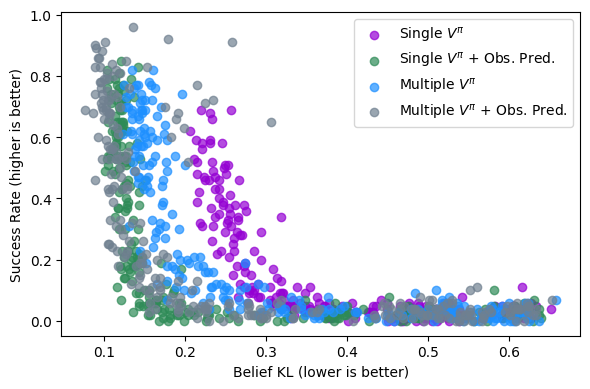

In [32]:

plt.figure(figsize=(6,4))

for i in range(25):
    df_common = comb(folder='test2',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7, label = 'Single $V^\pi$')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7, label = 'Single $V^\pi$ + Obs. Pred.')
    else:
        plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test3',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='dodgerblue', alpha=0.7, label = 'Multiple $V^\pi$')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='dodgerblue', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test4',i=i)
    #print(df_common)
    if i ==0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='slategray', alpha=0.7, label = 'Multiple $V^\pi$ + Obs. Pred.')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='slategray', alpha=0.7)

plt.xlabel("Belief KL (lower is better)")
plt.ylabel("Success Rate (higher is better)")
plt.legend()
plt.tight_layout()
#plt.xlim(0.08,0.7)
#plt.ylim(0.0,1.00)
#plt.xscale('exp')
plt.savefig("figures/KL_succ.pdf")

(0.0, 1.0)

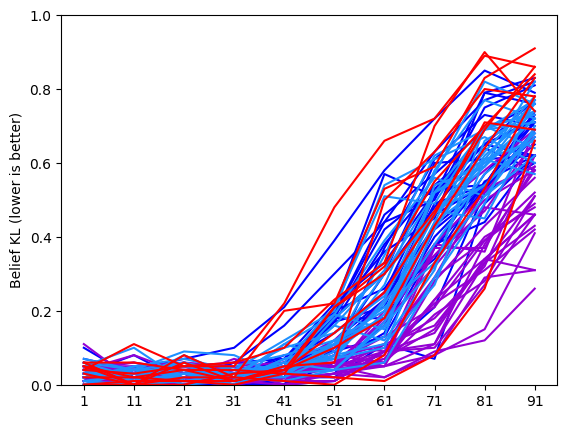

In [15]:
x = 'index'
y = 'success_rate'
for i in range(25):
    df_common = comb(folder='test',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='blue')

for i in range(25):
    df_common = comb(folder='test2',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='darkviolet')

for i in range(25):
    df_common = comb(folder='test3',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='dodgerblue')

for i in range(10):
    df_common = comb(folder='test4',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='red')

plt.xlabel("Chunks seen")
plt.ylabel("Belief KL (lower is better)")
#plt.xlim(0.08,0.7)
plt.ylim(0.0,1.00)
#plt.xscale('exp')

In [27]:
def extractor(folder, max_i):
    dfs = [comb(folder=folder,i=i) for i in range(max_i) ]
    for i, df in enumerate(dfs):
        df = df.copy()

        # Clean the index column
        df["index"] = pd.to_numeric(df["index"], errors="coerce")

        # # Optional: check if any conversion failed
        # if df["index"].isna().any():
        #     print(f"Warning: NaN created in df {i} during index conversion")

        # Set it as the actual index
        #df = df.set_index("index")

        dfs[i] = df
    # for df in dfs:
    #     df = df.copy()

    #     # Convert all columns except 'index' to numeric
    #     for col in df.columns:
    #         if col != "index":   # adjust if your index column name differs
    #             df[col] = pd.to_numeric(df[col], errors="coerce")

    #     cleaned_dfs.append(df)
    
    # Stack replicates along a new "replicate" axis
    panel = pd.concat(dfs, axis=0, keys=range(len(dfs)))

    #print(panel)
    #print(panel.dtypes)

    # Compute per-row means and stds across replicates
    mean_df = panel.groupby(level=1).mean()
    std_df  = panel.groupby(level=1).std()
    sem_df  = std_df/np.sqrt(max_i)

    return mean_df, std_df, sem_df



<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_939352/3115630015.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$', alpha=0.7, marker='o')
/tmp/ipykernel_939352/3115630015.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
/tmp/ipykernel_939352/3115630015.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Multiple $V^\pi$', alpha=0.7, marker='o')
/tmp/ipykerne

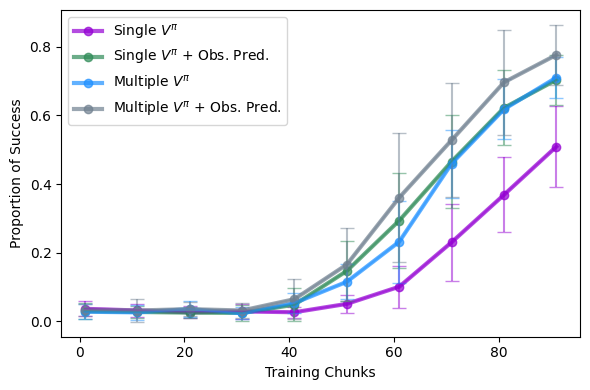

In [31]:
x = 'index'
#x = 'linear'
y = 'success_rate'
#y = 'linear'

plt.figure(figsize=(6,4))

mean_df, std_df, sem_df = extractor('test2',25)
col = 'darkviolet'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)


mean_df, std_df, sem_df = extractor('test',25)
col = 'seagreen'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)
col = 'dodgerblue'

mean_df, std_df, sem_df = extractor('test3',25)

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Multiple $V^\pi$', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)

mean_df, std_df, sem_df = extractor('test4',20)
col = 'slategray'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Multiple $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)

plt.xlabel("Training Chunks")
plt.ylabel("Proportion of Success")
plt.legend()
plt.tight_layout()
#plt.gca.invert_xaxis()
plt.savefig("figures/train_succ.pdf")